In [5]:
# ============================================
# CANONICAL PIPELINE: RAW DATA → DAILY METRICS
# ============================================

import pandas as pd
import numpy as np

# ---------- 1. Load raw data ----------
sentiment = pd.read_csv("../data/sentiment.csv")
trades = pd.read_csv("../data/trades.csv")

# ---------- 2. Sentiment preprocessing ----------
sentiment["date"] = pd.to_datetime(sentiment["date"]).dt.date

def map_sentiment(x):
    if "Fear" in x:
        return "Fear"
    elif "Greed" in x:
        return "Greed"
    else:
        return "Neutral"

sentiment["sentiment_group"] = sentiment["classification"].apply(map_sentiment)

# ---------- 3. Trade timestamp handling ----------
trades["timestamp_dt"] = pd.to_datetime(trades["Timestamp"], unit="ms", utc=True)
trades["date"] = trades["timestamp_dt"].dt.date

# ---------- 4. Find overlapping dates ----------
common_dates = set(trades["date"]).intersection(set(sentiment["date"]))

# ---------- 5. Filter to valid dates ----------
trades_filtered = trades[trades["date"].isin(common_dates)].copy()
sentiment_filtered = sentiment[sentiment["date"].isin(common_dates)].copy()

# ---------- 6. Base daily metrics ----------
daily_base = (
    trades_filtered
    .groupby(["Account", "date"])
    .agg(
        daily_pnl=("Closed PnL", "sum"),
        trade_count=("Trade ID", "count"),
        total_fees=("Fee", "sum")
    )
    .reset_index()
)

# ---------- 7. Average trade size ----------
avg_trade_size = (
    trades_filtered
    .groupby(["Account", "date"])["Size USD"]
    .mean()
    .reset_index(name="avg_trade_size_usd")
)

# ---------- 8. Trade bias ----------
side_counts = (
    trades_filtered
    .groupby(["Account", "date", "Side"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

def trade_bias(row):
    buy = row.get("BUY", 0)
    sell = row.get("SELL", 0)
    if buy > sell:
        return "Buy-biased"
    elif sell > buy:
        return "Sell-biased"
    else:
        return "Balanced"

side_counts["trade_bias"] = side_counts.apply(trade_bias, axis=1)

# ---------- 9. Merge all ----------
daily_metrics = (
    daily_base
    .merge(avg_trade_size, on=["Account", "date"], how="left")
    .merge(
        side_counts[["Account", "date", "trade_bias"]],
        on=["Account", "date"],
        how="left"
    )
    .merge(
        sentiment_filtered[["date", "sentiment_group"]],
        on="date",
        how="left"
    )
)

# ---------- 10. Final sanity check ----------
daily_metrics.head(), daily_metrics.shape


(                                      Account        date     daily_pnl  \
 0  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-10-27 -3.275059e+05   
 1  0x083384f897ee0f19899168e3b1bec365f52a9012  2025-02-19  1.927736e+06   
 2  0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd  2024-10-27  2.060745e+04   
 3  0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd  2025-02-19  1.709873e+04   
 4  0x271b280974205ca63b716753467d5a371de622ab  2024-07-03 -1.000000e+00   
 
    trade_count   total_fees  avg_trade_size_usd   trade_bias sentiment_group  
 0          462  1112.895650        14810.891818  Sell-biased           Greed  
 1         3356  6292.416654        16345.241940  Sell-biased            Fear  
 2          320   202.167151         2492.749906  Sell-biased           Greed  
 3         3533  1664.914670         1693.351684  Sell-biased            Fear  
 4            5    10.197932         6070.200000  Sell-biased         Neutral  ,
 (77, 8))

In [ ]:
import pandas as pd

sentiment = pd.read_csv("../data/sentiment.csv")
trades = pd.read_csv("../data/trades.csv")

print(sentiment.head())
print(trades.head())


In [ ]:
sentiment.shape


In [ ]:
sentiment.columns


In [ ]:
sentiment.isna().sum()

In [ ]:
sentiment.duplicated().sum()

In [ ]:
trades.shape

In [ ]:
trades.columns

In [ ]:
trades.isna().sum().sort_values(ascending=False).head(10)

In [ ]:
trades.duplicated().sum()

In [ ]:
trades[["Timestamp", "Timestamp IST"]].head()


In [ ]:
trades["timestamp_dt"] = pd.to_datetime(
    trades["Timestamp"],
    unit="ms",
    utc=True
)


In [ ]:
trades[["Timestamp", "timestamp_dt"]].head()


In [ ]:
trades["date"] = trades["timestamp_dt"].dt.date


In [ ]:
trades["date"].head()


In [ ]:
sentiment["date"] = pd.to_datetime(sentiment["date"]).dt.date


In [ ]:
sentiment["date"].min(), sentiment["date"].max()


In [ ]:
trades["date"].min(), trades["date"].max()

In [ ]:
common_dates = set(trades["date"]).intersection(set(sentiment["date"]))
len(common_dates)


In [ ]:
min(common_dates), max(common_dates)


In [ ]:
valid_dates = set(common_dates)

trades_filtered = trades[trades["date"].isin(valid_dates)].copy()


In [ ]:
trades_filtered.shape


In [ ]:
sentiment_filtered = sentiment[sentiment["date"].isin(valid_dates)].copy()
sentiment_filtered[["date", "classification", "value"]]


In [ ]:
def map_sentiment(x):
    if "Fear" in x:
        return "Fear"
    elif "Greed" in x:
        return "Greed"
    else:
        return "Neutral"

sentiment_filtered["sentiment_group"] = sentiment_filtered["classification"].apply(map_sentiment)


In [ ]:
    sentiment_filtered[["date", "classification", "sentiment_group"]]


In [ ]:
sentiment_filtered["sentiment_group"].value_counts()


In [ ]:
daily_base = (
    trades_filtered
    .groupby(["Account", "date"])
    .agg(
        daily_pnl=("Closed PnL", "sum"),
        trade_count=("Trade ID", "count"),
        total_fees=("Fee", "sum")
    )
    .reset_index()
)


In [ ]:
daily_base.head()
daily_base.shape


In [ ]:
avg_trade_size = (
    trades_filtered
    .groupby(["Account", "date"])["Size USD"]
    .mean()
    .reset_index(name="avg_trade_size_usd")
)


In [ ]:
side_counts = (
    trades_filtered
    .groupby(["Account", "date", "Side"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)


In [ ]:
side_counts["buy_sell_ratio"] = (
    side_counts.get("BUY", 0) / (side_counts.get("SELL", 1))
)


In [ ]:
daily_metrics = (
    daily_base
    .merge(avg_trade_size, on=["Account", "date"], how="left")
    .merge(
        side_counts[["Account", "date", "buy_sell_ratio"]],
        on=["Account", "date"],
        how="left"
    )
)


In [ ]:
daily_metrics.head()
daily_metrics.describe()


In [ ]:
def trade_bias(row):
    buy = row.get("BUY", 0)
    sell = row.get("SELL", 0)

    if buy > sell:
        return "Buy-biased"
    elif sell > buy:
        return "Sell-biased"
    else:
        return "Balanced"


In [ ]:
side_counts["trade_bias"] = side_counts.apply(trade_bias, axis=1)


In [ ]:
daily_metrics = (
    daily_base
    .merge(avg_trade_size, on=["Account", "date"], how="left")
    .merge(
        side_counts[["Account", "date", "trade_bias"]],
        on=["Account", "date"],
        how="left"
    )
)


In [ ]:
daily_metrics.head()
daily_metrics.describe()
daily_metrics["trade_bias"].value_counts()


In [ ]:
daily_metrics = daily_metrics.merge(
    sentiment_filtered[["date", "sentiment_group"]],
    on="date",
    how="left"
)


In [ ]:
daily_metrics["sentiment_group"].value_counts()


In [ ]:
daily_metrics.groupby("sentiment_group")[
    ["daily_pnl", "trade_count", "avg_trade_size_usd"]
].mean()


In [ ]:
daily_metrics.groupby("sentiment_group")["daily_pnl"].describe()


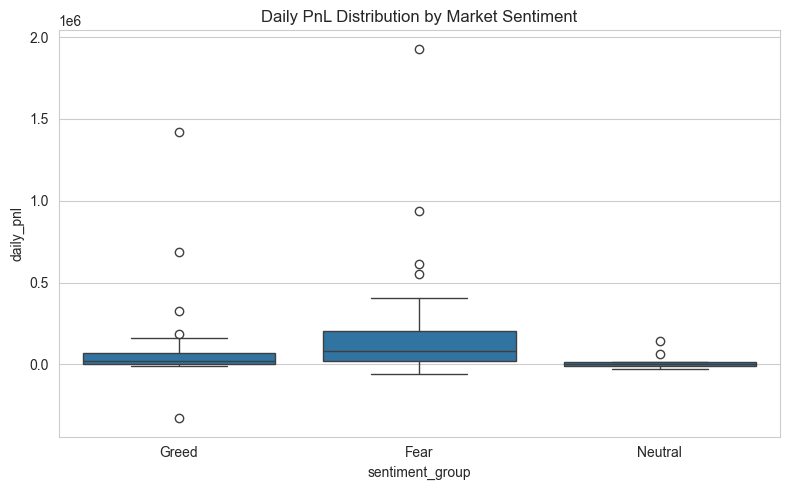

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.boxplot(data=daily_metrics, x="sentiment_group", y="daily_pnl")
plt.title("Daily PnL Distribution by Market Sentiment")
plt.tight_layout()
plt.show()


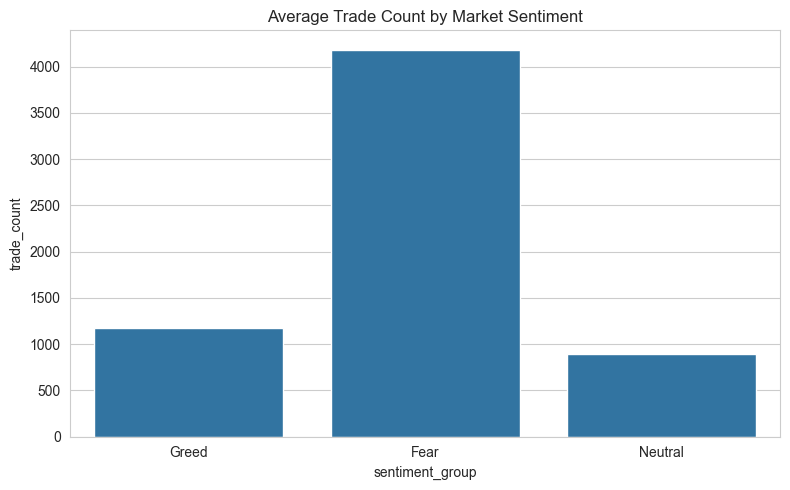

In [7]:
plt.figure(figsize=(8,5))
sns.barplot(
    data=daily_metrics,
    x="sentiment_group",
    y="trade_count",
    estimator=np.mean,
    errorbar=None
)
plt.title("Average Trade Count by Market Sentiment")
plt.tight_layout()
plt.show()


In [9]:
import os

os.makedirs("../outputs/charts", exist_ok=True)
os.makedirs("../outputs/tables", exist_ok=True)



In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.boxplot(
    data=daily_metrics,
    x="sentiment_group",
    y="daily_pnl"
)
plt.title("Daily PnL Distribution by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Daily PnL")
plt.tight_layout()

plt.savefig("../outputs/charts/pnl_by_sentiment.png", dpi=300)
plt.close()


In [11]:
plt.figure(figsize=(8,5))
sns.barplot(
    data=daily_metrics,
    x="sentiment_group",
    y="trade_count",
    estimator=np.mean,
    errorbar=None
)
plt.title("Average Trade Count by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Trades per Trader-Day")
plt.tight_layout()

plt.savefig("../outputs/charts/trade_count_by_sentiment.png", dpi=300)
plt.close()


In [12]:
bias_table = pd.crosstab(
    daily_metrics["sentiment_group"],
    daily_metrics["trade_bias"],
    normalize="index"
)

bias_table.plot(
    kind="bar",
    stacked=True,
    figsize=(8,5)
)
plt.title("Trade Direction Bias by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Proportion")
plt.legend(title="Trade Bias")
plt.tight_layout()

plt.savefig("../outputs/charts/trade_bias_by_sentiment.png", dpi=300)
plt.close()
